# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [11]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [12]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [13]:
type(registros)

list

In [14]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [15]:
dados = pd.DataFrame(registros)

In [16]:
print("Primeiros Registros: ")
display(dados.head())

Primeiros Registros: 


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [17]:
print("Dimensões do DataFrame: ")
print(f"Linhas: {dados.shape[0]}")
print(f"Colunas: {dados.shape[1]}")

Dimensões do DataFrame: 
Linhas: 336
Colunas: 11


In [18]:
print("Atributos: \n")
print(dados.columns.tolist())

Atributos: 

['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']


In [19]:
print("Informações do DataFrame: \n")
dados.info()

Informações do DataFrame: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [20]:
print("Estatísticas descritivas: \n")
dados.describe()

Estatísticas descritivas: 



,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


O atributo ***cod_areacarga*** representa a área de carga analisada. Os atributos ***dat_referencia*** e ***din_referenciautc*** representam a referência de data e data/hora dos registros. O atributo ***val_cargaglobal*** representa o valor da carga elétrica.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [21]:
dados = dados.rename(columns = {'cod_areacarga': 'area',
                                'dat_referencia':'data',
                                'din_referenciautc': 'data_hora',
                                'val_cargaglobal': 'carga'
})

In [22]:
dados = dados[['area', 'data', 'data_hora', 'carga']]

In [23]:
print("Valores Ausentes: \n")
display(dados.isnull().sum())

Valores Ausentes: 



,0
area,0
data,0
data_hora,0
carga,0


In [24]:
print("Tipos de dados:")
print(dados.dtypes)

Tipos de dados:
area          object
data          object
data_hora     object
carga        float64
dtype: object


In [25]:
dados['carga'] = pd.to_numeric(
    dados['carga'],
    errors="coerce"
)

dados['data_hora'] = pd.to_datetime(
    dados['data_hora'],
    errors="coerce"
)

In [26]:
print("DataFrame organizado: ")
display(dados.head())

DataFrame organizado: 


,area,data,data_hora,carga
0,SP,2025-08-01,2025-08-01 03:30:00+00:00,15913.618
1,SP,2025-08-01,2025-08-01 04:00:00+00:00,15251.414
2,SP,2025-08-01,2025-08-01 04:30:00+00:00,14606.733
3,SP,2025-08-01,2025-08-01 05:00:00+00:00,14182.290
4,SP,2025-08-01,2025-08-01 05:30:00+00:00,13838.488


In [27]:
print("Tipos após tratamento: ")
print(dados.dtypes)

Tipos após tratamento: 
area                      object
data                      object
data_hora    datetime64[ns, UTC]
carga                    float64
dtype: object


Foi realizada a renomeação dos atributos para faciliar a análise. A variável de carga foi convertida para formato numérico e a variável data/hora foi convertida para formato datetime. Foi verificada a ocorrência de valores ausentes em cada atributo.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [28]:
carga_minima = dados['carga'].min()
carga_maxima = dados['carga'].max()
carga_media = dados['carga'].mean()
mediana = dados['carga'].median()
amplitude = carga_maxima - carga_minima
total_medicoes = dados['carga'].count()

print(f"Carga Mínima: {carga_minima:.4f} MWmed")
print(f"Carga Máxima: {carga_maxima:.4f} MWmed")
print(f"Carga Média: {carga_media:.4f} MWmed")
print(f"Mediana: {mediana:.4f} MWmed")
print(f"Amplitude: {amplitude:.4f} MWmed")
print(f"Total de Medições: {total_medicoes}")

Carga Mínima: 12139.2530 MWmed
Carga Máxima: 23185.3120 MWmed
Carga Média: 17870.8290 MWmed
Mediana: 18199.1285 MWmed
Amplitude: 11046.0590 MWmed
Total de Medições: 336


In [29]:
diferenca = carga_maxima - carga_media
print(f"O valor máximo está {diferenca:.4f} MWmed acima da média")

O valor máximo está 5314.4830 MWmed acima da média


O valor máximo de carga está quase 30% acima do valor médio. A mediana, entretanto, está próxima ao valor médio, indicando que o valor máximo representa um pico em relação ao comportamento normal dos dados.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [30]:
limiar = .9 * carga_maxima
print(f"Limiar de alta demanda: {limiar:.4f} MWmed")

Limiar de alta demanda: 20866.7808 MWmed


In [31]:
alta_demanda = dados[dados['carga'] > limiar]
alta_demanda.head()

,area,data,data_hora,carga
35,SP,2025-08-01,2025-08-01 21:00:00+00:00,21088.959
36,SP,2025-08-01,2025-08-01 21:30:00+00:00,22398.360
37,SP,2025-08-01,2025-08-01 22:00:00+00:00,23185.312
38,SP,2025-08-01,2025-08-01 22:30:00+00:00,22903.314
39,SP,2025-08-01,2025-08-01 23:00:00+00:00,22358.701


In [32]:
qtd_alta_demanda = len(alta_demanda)
print(f"Quantidad de registros acima do limite: {qtd_alta_demanda}")

Quantidad de registros acima do limite: 50


In [33]:
porcentagem_alta_demanda = (qtd_alta_demanda / total_medicoes) * 100
print(f"Porcentagem de valores acima do limite: {porcentagem_alta_demanda:.2f}%")

Porcentagem de valores acima do limite: 14.88%


In [34]:
pico = dados.loc[dados['carga'].idxmax()]
display(pico[['carga', 'data_hora']])

,37
carga,23185.312
data_hora,2025-08-01 22:00:00+00:00


Os periodos acima do limiar representam, aproximadamente, 15% dos registros, sendo uma parcela pequena do período analisado.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

O critério utilizado será o de *carga acima da média*

In [35]:
acima_media = dados[dados['carga'] > carga_media]
acima_media.head()

,area,data,data_hora,carga
15,SP,2025-08-01,2025-08-01 11:00:00+00:00,18096.023
16,SP,2025-08-01,2025-08-01 11:30:00+00:00,18629.395
17,SP,2025-08-01,2025-08-01 12:00:00+00:00,18825.176
18,SP,2025-08-01,2025-08-01 12:30:00+00:00,19056.504
19,SP,2025-08-01,2025-08-01 13:00:00+00:00,19427.822


In [36]:
qtd_acima_media = len(acima_media)
print(f"Quantidade de registros: {qtd_acima_media}")

Quantidade de registros: 184


In [37]:
percentual_acima_media = (qtd_acima_media / total_medicoes) * 100
print(f"Percentual de registros acima da média: {percentual_acima_media:.2f}%")

Percentual de registros acima da média: 54.76%


In [38]:
comparacao = pd.DataFrame({
    "Critério": [
        "Alta demanda (> 90% do máximo)",
        "Carga acima da média"
    ],
    "Quantidade": [
        qtd_alta_demanda,
        qtd_acima_media
    ],
    "Percentual (%)": [
        porcentagem_alta_demanda,
        percentual_acima_media
    ]
})

print("\nComparação:")
display(comparacao)


Comparação:


,Critério,Quantidade,Percentual (%)
0,Alta demanda (> 90% do máximo),50,14.880952
1,Carga acima da média,184,54.761905


## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

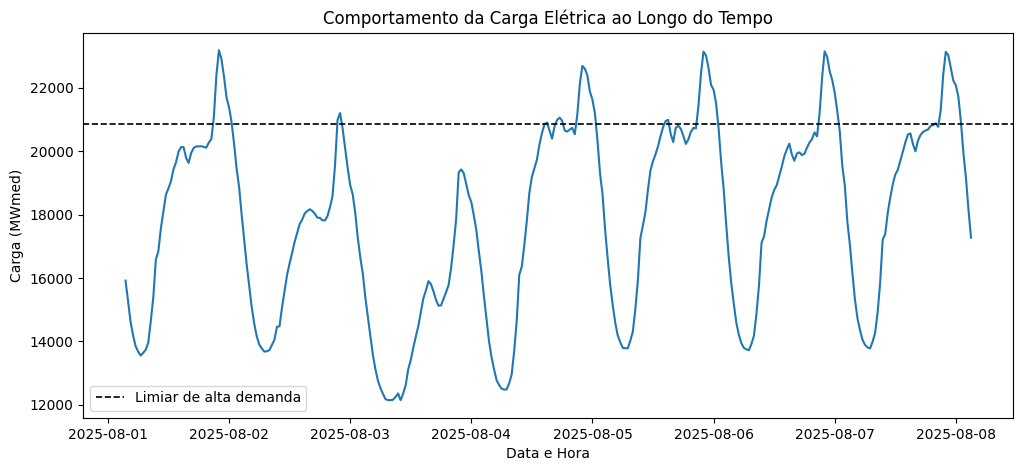

In [39]:
dados_grafico = dados.sort_values('data_hora').copy()

plt.figure(figsize=(12, 5))

plt.plot(dados_grafico['data_hora'], dados_grafico['carga'], linewidth = 1.5)

plt.axhline(limiar, linestyle = "--", linewidth = 1.2, label = "Limiar de alta demanda", color = "k")

plt.title("Comportamento da Carga Elétrica ao Longo do Tempo")
plt.xlabel("Data e Hora")
plt.ylabel("Carga (MWmed)")

plt.legend()

plt.show()

O gráfico apresenta a variação da carga elétrica ao longo do período analisado. É possível identificar oscilações na demanda e visualizar os momentos em que os valores ultrapassam o limiar de alta demanda.

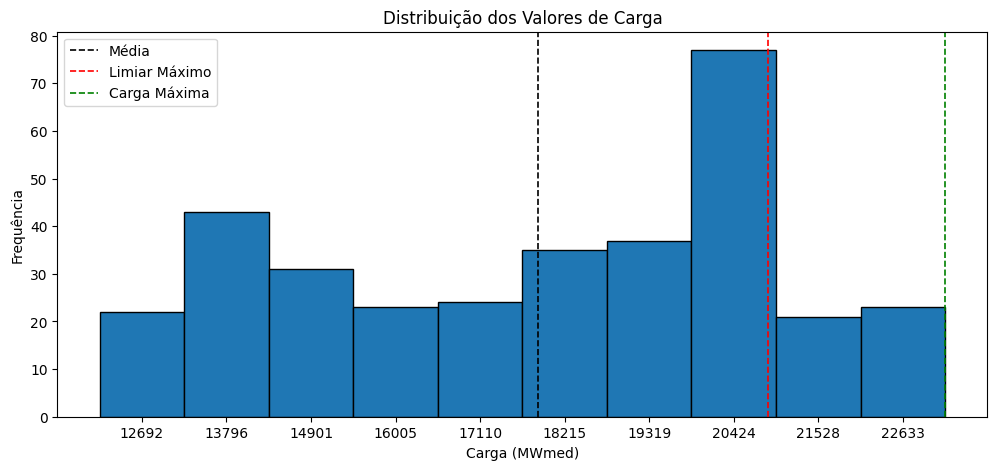

In [40]:
plt.figure(figsize=(12, 5))

frequencias, limites, _ = plt.hist(dados['carga'], bins=10, edgecolor="k")
centros = (limites[:-1] + limites[1:]) / 2

plt.xticks(centros, [f"{x:.0f}" for x in centros], rotation = 0)

plt.axvline(carga_media, linestyle = "--", linewidth = 1.2, label = "Média", color = "k")
plt.axvline(limiar, linestyle = "--", linewidth = 1.2, label = "Limiar Máximo", color = "r")
plt.axvline(carga_maxima, linestyle = "--", linewidth = 1.2, label = "Carga Máxima", color = "g")

plt.title("Distribuição dos Valores de Carga")
plt.xlabel("Carga (MWmed)")
plt.ylabel("Frequência")

plt.legend()
plt.show()



O histograma mostra a distribuição dos valores de carga observados. Ele permite verificar em quais faixas os valores aparecem com maior frequência e comparar a distribuição com a média e o limite máximo.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [41]:
indice_pico = dados['carga'].idxmax()
momento_pico = dados.loc[indice_pico, 'data_hora']

regiao = dados['area'].iloc[0]

periodo_inicio = dados['data_hora'].min()
periodo_final = dados['data_hora'].max()

resumo_resultados = f'''
Região analisada: {regiao}
Período analisado: {periodo_inicio} até {periodo_final}

Quantidade de registros: {total_medicoes}
Carga mínima: {carga_minima:.4f} MWmed
Carga máxima: {carga_maxima:.4f} MWmed
Carga média: {carga_media:.4f} MWmed
Mediana: {mediana:.4f} MWmed

Limiar de alta demanda: {limiar:.4f} MWmed
Registros de alta demanda: {qtd_alta_demanda}
Percentual de alta demanda: {porcentagem_alta_demanda}

Momento do pico: {momento_pico}

Segundo critério: Carga Acima da Média
Registros acima da média: {qtd_acima_media}
Percentual acima da média: {percentual_acima_media:.2f}%
'''

print(resumo_resultados)


Região analisada: SP
Período analisado: 2025-08-01 03:30:00+00:00 até 2025-08-08 03:00:00+00:00

Quantidade de registros: 336
Carga mínima: 12139.2530 MWmed
Carga máxima: 23185.3120 MWmed
Carga média: 17870.8290 MWmed
Mediana: 18199.1285 MWmed

Limiar de alta demanda: 20866.7808 MWmed
Registros de alta demanda: 50
Percentual de alta demanda: 14.880952380952381

Momento do pico: 2025-08-01 22:00:00+00:00

Segundo critério: Carga Acima da Média
Registros acima da média: 184
Percentual acima da média: 54.76%



# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [46]:
!pip -q install -U google-genai

In [43]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [44]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [45]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

**RELATÓRIO TÉCNICO DE ANÁLISE DE DEMANDA ELÉTRICA – REGIÃO SP**

---

### 1. Caracterização do Conjunto Analisado
* **Região:** São Paulo (SP)
* **Período de Análise:** De 01/08/2025 às 03:30:00+00:00 a 08/08/2025 às 03:00:00+00:00
* **Volume de Dados:** 336 registros temporais

---

### 2. Principais Indicadores
Com base na amostra de 336 registros, os parâmetros estatísticos do perfil de carga foram:

* **Carga Mínima:** 12.139,2530 MWmed
* **Carga Máxima (Pico):** 23.185,3120 MWmed
* **Carga Média:** 17.870,8290 MWmed
* **Mediana:** 18.199,1285 MWmed
* **Momento do Pico de Carga:** 01/08/2025 às 22:00:00+00:00

*Resultado observado:* A mediana (18.199,13 MWmed) apresentou valor ligeiramente superior à média (17.870,83 MWmed), indicando que em mais da metade do tempo a carga se manteve acima do valor médio calculado.

---

### 3. Análise dos Períodos de Alta Demanda
* **Limiar de Alta Demanda:** 20.866,7808 MWmed
* **Ocorrências de Alta Demanda:** 50 registros
* **Proporção no Perío

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

### Validação crítica

1. **Os indicadores foram utilizados corretamente?**  
Sim. Os indicadores foram calculados corretamente a partir dos dados obtidos da API e correspondem aos valores de carga mínima, máxima, média, mediana e ao limiar de alta demanda.

2. **Há alguma afirmação que não pode ser confirmada pelos dados?**  
As afirmações que descrevem causas para aumentos ou reduções da carga não podem ser confirmadas somente pelos dados analisados. Por isso, a IA trata essas afirmações como hipóteses.

3. **Houve interpretação exagerada ou causalidade não demonstrada?**  
A IA apresentou hipóteses, como fatores climáticos, como possíveis causas dos picos. Porém, deixou claro que essas possibilidades não podem ser comprovadas pelos dados, enfatizando que estas hipóteses devem ser tratadas como tal.

4. **Que alterações a equipe realizou no texto?**  
A equipe não realizou alterações drásticas no texto. Foram mantidos os resultados obtidos nos cálculos e foram enfatizadas as diferenças entre observações dos dados e possíveis hipóteses. Além disso, foi adicionada uma análise dos gráficos.

## **RELATÓRIO FINAL: ANÁLISE DE CARGA ELÉTRICA – REGIÃO SP**

---

### 1. Caracterização do Conjunto Analisado
O presente relatório analisa os dados de carga elétrica da região de **São Paulo (SP)** referentes ao período compreendido entre **01/08/2025 às 03:30:00 (UTC)** e **08/08/2025 às 03:00:00 (UTC)**.

O conjunto analisado possui **336 registros** temporais sequenciais. Esses dados foram utilizados para identificar períodos de alta demanda e comparar diferentes critérios de classificação da carga.

---

### 2. Principais Indicadores
Os dados estatísticos descritivos apurados para o período são:

*   **Carga Média:** 17.870,8290 MWmed
*   **Mediana:** 18.199,1285 MWmed
*   **Carga Mínima:** 12.139,2530 MWmed
*   **Carga Máxima (Pico):** 23.185,3120 MWmed
*   **Momento de Pico:** 01/08/2025 às 22:00:00 (UTC)

A diferença entre a Carga Máxima e a Carga Média foi de 5.314,4830 MWmed.

*Nota estatística:* A mediana levemente superior à média reflete a distribuição dos valores ao longo do período, indicando que em mais da metade do tempo a carga esteve acima de 18.199,13 MWmed. Porém, como a diferença é pequena, os valores centrais apresentam comportamento semelhante

---

### 3. Análise dos Períodos de Alta Demanda
Para a identificação de eventos pontuais de elevada demanda, adotou-se o limiar fixado em **20.866,7808 MWmed**, correspondente a registros com a carga superior a 90% da carga máxima.

*   **Registros de Alta Demanda:** 50
*   **Percentual do Período em Alta Demanda:** 14,88%

**Observação analítica sobre causabilidade:**
*   **Resultado observado:** A carga atingiu seu valor máximo no dia 01/08/2025 às 22:00:00 UTC, e o estado de alta demanda permaneceu ativo em 14,88% dos registros.
*   **Hipóteses (não comprovadas pelos dados):** Os dados fornecidos não contêm variáveis meteorológicas (temperatura/umidade), econômicas ou operacionais. Portanto, qualquer atribuição de causa para os picos de demanda (como uso intensivo de ar-condicionado, dinâmica industrial ou fatores climáticos) constitui meramente uma **hipótese não sustentada pela base de dados atual**.

---

### 4. Comparação com o Segundo Critério
Foi avaliado um segundo critério de classificação: **Carga Acima da Média** (valores > 17.870,8290 MWmed).

*   **Critério 1 (Alta Demanda > 20.866,78 MWmed):** 50 registros (**14,88%** do total).
*   **Critério 2 (Acima da Média > 17.870,83 MWmed):** 184 registros (**54,76%** do total).

**Comparativo:**
O critério de *Carga Acima da Média* abrange a maioria do período analisado (54,76%), capturando o comportamento operacional de rotina acima do ponto central. Já o critério de *Alta Demanda* funciona de forma mais seletiva, isolando apenas os 14,88% de registros que representam patamares significativamente mais elevados de consumo.

---

### 5. Análise dos Gráficos

O gráfico da carga ao longo do tempo permite observar as oscilações da demanda durante o período e identificar os momentos em que o valor se aproxima do pico.

O histograma apresenta a distribuição dos valores de carga e permite observar em quais faixas ocorreram mais medições. A comparação com a média e com o limiar ajuda a visualizar a diferença entre o comportamento dos dados centrais e dos valores de pico

---

### 6. Conclusão
Com base **estritamente nos dados fornecidos**:
1. O sistema da região SP operou com uma carga média de 17.870,83 MWmed durante os 7 dias analisados.
2. O consumo ultrapassou a média em 54,76% do tempo total.
3. Eventos de alta demanda (superiores a 20.866,78 MWmed) representaram 14,88% do período, tendo o ponto máximo absoluto registrado em 01/08/2025 às 22:00:00 UTC (23.185,31 MWmed).
4. Para a determinação das causas reais da variação de carga e dos momentos de pico, faz-se necessária a inclusão de bases de dados complementares (ex.: dados climáticos e de calendário operacional).


---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**